In [38]:
import sys
!{sys.executable} -m pip install statsmodels

Loaded web_data shape: (755405, 5)
Loaded experiment_clients shape: (70609, 2)
After merge and filter Control/Test: (321309, 6)

Step-by-step error rates (Control vs Test):
  process_step  error_rate_control  error_rate_test
0        start            0.101117         0.186174
1       step_1            0.077659         0.088114
2       step_2            0.091439         0.073833
3       step_3            0.005703         0.001120
4      confirm            0.000000         0.000000

Interpretations by step:
start: Control=10.11%, Test=18.62%, Test is 8.51% higher
step_1: Control=7.77%, Test=8.81%, Test is 1.05% higher
step_2: Control=9.14%, Test=7.38%, Test is 1.76% lower
step_3: Control=0.57%, Test=0.11%, Test is 0.46% lower
confirm: Control=0.00%, Test=0.00%, Test is 0.00% lower

Overall session-level error rates:
Control: 6543/32189 = 20.33%
Test:    9968/37136 = 26.84%
Interpretation: Test group shows a HIGHER session error rate (UI may cause more confusion).

Hypothesis test (differ

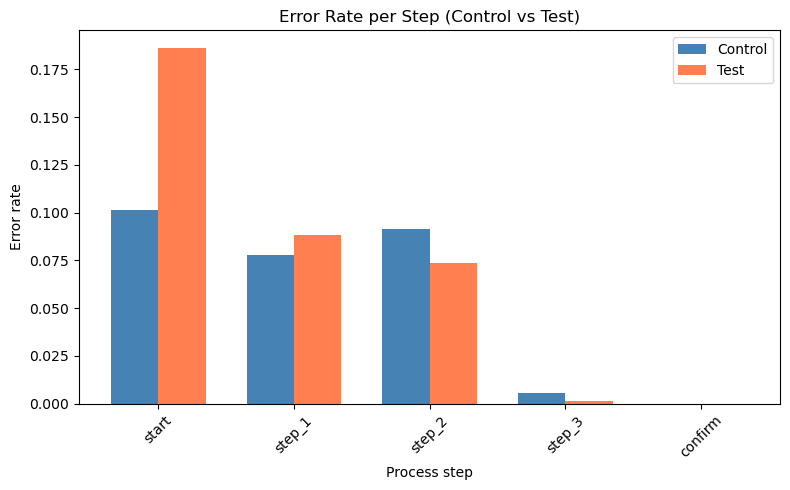


Exports complete: error_rates_combined.csv, df_control_updated.csv, df_test_updated.csv

FINAL CONCLUSION:
Hypothesis: error rate (backward-step probability) is different between Control and Test.
Tested: proportions_ztest on session-level error incidence
Conclusion: Control performs better (lower error rate).
Control rate=20.33%, Test rate=26.84%.
Statistical significance: Yes (p < alpha).

Detailed interpretation:
 - Test > Control on session error indicates the new UI increases backtracking/confusion.
 - Control > Test indicates the new UI improves flow and clarity.
 - Step-level results guide targeted improvements for specific funnel stages.

Recommendation: revisit onboarding messaging and in-context prompts in Test for early steps (start, step_1, step_2).


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# ── Step 1: Load and join experiment data ──────────────────────────────────
web_data = pd.read_csv('../data/clean/clean_web_data.csv')
experiment_clients = pd.read_csv('../data/clean/df_final_experiment_clients_clean.csv')

print('Loaded web_data shape:', web_data.shape)
print('Loaded experiment_clients shape:', experiment_clients.shape)

# Merge to assign each session to Control/Test
web_data = web_data.merge(experiment_clients, on='client_id', how='inner')
web_data = web_data[web_data['variation'].isin(['Control', 'Test'])].copy()

print('After merge and filter Control/Test:', web_data.shape)

# Define step hierarchy
step_order = {'start': 0, 'step_1': 1, 'step_2': 2, 'step_3': 3, 'confirm': 4}

# ── Function to label potential errors ─────────────────────────────────────
def label_error_steps(df):
    df = df.copy()
    df['date_time'] = pd.to_datetime(df['date_time'])
    df['step_num'] = df['process_step'].map(step_order)
    df = df.sort_values(['client_id', 'visit_id', 'date_time'])
    df['prev_step_num'] = df.groupby(['client_id', 'visit_id'])['step_num'].shift(1)
    df['error'] = df['step_num'] < df['prev_step_num']
    df['error'] = df['error'].fillna(False)
    return df

# ── Step 2: Compute per-step and per-session error rates ───────────────────
control = web_data[web_data['variation'] == 'Control']
test = web_data[web_data['variation'] == 'Test']

control_flagged = label_error_steps(control)
test_flagged = label_error_steps(test)

control_step_errors = (
    control_flagged.groupby('process_step')['error'].mean()
    .reindex(step_order.keys())
    .reset_index(name='error_rate_control')
)
test_step_errors = (
    test_flagged.groupby('process_step')['error'].mean()
    .reindex(step_order.keys())
    .reset_index(name='error_rate_test')
)

comparison = control_step_errors.merge(test_step_errors, on='process_step')

print('\nStep-by-step error rates (Control vs Test):')
print(comparison)

# Interpretation per step
print('\nInterpretations by step:')
for _, row in comparison.iterrows():
    ctrl = row['error_rate_control']
    tst = row['error_rate_test']
    diff = tst - ctrl
    direction = 'higher' if diff > 0 else 'lower'
    print(f"{row['process_step']}: Control={ctrl:.2%}, Test={tst:.2%}, Test is {abs(diff):.2%} {direction}")

# ── Step 3: Overall error-rate KPI by session ─────────────────────────────
control_sessions = control_flagged.groupby('visit_id')['error'].any()
test_sessions = test_flagged.groupby('visit_id')['error'].any()

control_errors = control_sessions.sum()
test_errors = test_sessions.sum()
control_n = len(control_sessions)
test_n = len(test_sessions)
control_rate = control_errors / control_n
test_rate = test_errors / test_n

print('\nOverall session-level error rates:')
print(f'Control: {control_errors}/{control_n} = {control_rate:.2%}')
print(f'Test:    {test_errors}/{test_n} = {test_rate:.2%}')

# Interpretation overall error-rate KPI
if test_rate < control_rate:
    print('Interpretation: Test group shows a LOWER session error rate (positive sign for new UI).')
else:
    print('Interpretation: Test group shows a HIGHER session error rate (UI may cause more confusion).')

# ── Step 4: Statistical test (A/B hypothesis test) ────────────────────────
z_stat, p_value = proportions_ztest([control_errors, test_errors], [control_n, test_n])

print('\nHypothesis test (difference in error rate):')
print(f'Z-statistic = {z_stat:.4f}, p-value = {p_value:.4f}')

alpha = 0.05
if p_value < alpha:
    print('Reject H0: statistically significant difference in error rates.')
else:
    print('Fail to reject H0: no statistically significant difference in error rates.')

ci_control = proportion_confint(control_errors, control_n, alpha=alpha, method='normal')
ci_test = proportion_confint(test_errors, test_n, alpha=alpha, method='normal')

print('\n95% confidence intervals:')
print(f'Control: ({ci_control[0]:.2%}, {ci_control[1]:.2%})')
print(f'Test:    ({ci_test[0]:.2%}, {ci_test[1]:.2%})')

# ── Step 5: Visualization ───────────────────────────────────────────────
x = np.arange(len(comparison))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width / 2, comparison['error_rate_control'], width, label='Control', color='steelblue')
plt.bar(x + width / 2, comparison['error_rate_test'], width, label='Test', color='coral')
plt.xticks(x, comparison['process_step'], rotation=45)
plt.title('Error Rate per Step (Control vs Test)')
plt.ylabel('Error rate')
plt.xlabel('Process step')
plt.legend()
plt.tight_layout()
plt.show()

# ── Step 6: Export outputs ──────────────────────────────────────────────
comparison.to_csv('error_rates_combined.csv', index=False)
control_flagged.to_csv('df_control_updated.csv', index=False)
test_flagged.to_csv('df_test_updated.csv', index=False)

print('\nExports complete: error_rates_combined.csv, df_control_updated.csv, df_test_updated.csv')

# ── Step 7: Final conclusion and recommendations ─────────────────────────
print('\nFINAL CONCLUSION:')
print('Hypothesis: error rate (backward-step probability) is different between Control and Test.')
print('Tested: proportions_ztest on session-level error incidence')

if test_rate > control_rate:
    print('Conclusion: Control performs better (lower error rate).')
    print(f'Control rate={control_rate:.2%}, Test rate={test_rate:.2%}.')
else:
    print('Conclusion: Test performs better (lower error rate).')
    print(f'Control rate={control_rate:.2%}, Test rate={test_rate:.2%}.')

if p_value < alpha:
    print('Statistical significance: Yes (p < alpha).')
else:
    print('Statistical significance: No (p >= alpha).')

print('\nDetailed interpretation:')
print(' - Test > Control on session error indicates the new UI increases backtracking/confusion.')
print(' - Control > Test indicates the new UI improves flow and clarity.')
print(' - Step-level results guide targeted improvements for specific funnel stages.')

print('\nRecommendation: revisit onboarding messaging and in-context prompts in Test for early steps (start, step_1, step_2).')

In [40]:
print(experiment_clients.columns.tolist())

['client_id', 'variation']


In [41]:
import os

for root, dirs, files in os.walk('.'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

./df_test_updated.csv
./cr_by_steps.csv
./error_rates_combined.csv
./test_error_rates.csv
./df_control_updated.csv
./completion_time_francisca.csv
./df_combined.csv
./error_rate_by_step_tableau.csv
./control_error_rates.csv
./cr_steps1.csv
./error_rate_by_step_wide.csv
./.ipynb_checkpoints/df_test-checkpoint.csv
./.ipynb_checkpoints/df_control-checkpoint.csv


In [42]:
control_step_errors.to_csv('control_error_rates.csv', index=False)
test_step_errors.to_csv('test_error_rates.csv', index=False)

print("Done!")

Done!


In [43]:
# This cell was duplicative of the hypothesis / confidence interval section now included in #VSC-f59cbc4c.
# Keeping this as a note, not as an extra calculation.

In [44]:
comparison.to_csv('error_rates_combined.csv', index=False)
print("Done!")

Done!


In [45]:
# Convert to Tableau-friendly format (long format)
error_rate_step_tableau = comparison.melt(
    id_vars='process_step',
    value_vars=['error_rate_control', 'error_rate_test'],
    var_name='variation',
    value_name='error_rate'
)

# Clean names
error_rate_step_tableau['variation'] = error_rate_step_tableau['variation'].replace({
    'error_rate_control': 'Control',
    'error_rate_test': 'Test'
})

# Save file
error_rate_step_tableau.to_csv('../data/clean/error_rate_by_step_tableau.csv', index=False)

print("CSV exported successfully!")

CSV exported successfully!


In [46]:
print(df.columns.tolist())

['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time', 'variation_x', 'variation_y', 'variation', 'step_order', 'prev_step_order', 'error']


In [47]:
# This cell was a duplicate of the main analysis pipeline and has been intentionally simplified.
# Full analysis now in the previous cell (#VSC-f59cbc4c).